# Minimum Atomworks Output Analysis

This notebook reads `pdb.parquet` and `dataset.parquet` directly from a run output directory, summarizes the contents, and makes a few quick matplotlib plots for structure-, interface-, and dataset-level inspection.

Edit `OUT_DIR` in the next cell if you want to force a specific run directory.

In [8]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

out_dir = Path('/home/eva/20260308_minimum_atomworks/minimum_atw_realdata_all_non_rosetta')

pdb_path = out_dir / 'pdb.parquet'
dataset_path = out_dir / 'dataset.parquet'
run_metadata_path = out_dir / 'run_metadata.json'
dataset_metadata_path = out_dir / 'dataset_metadata.json'

print(f'Using out_dir: {out_dir}')
print(f'pdb.parquet exists: {pdb_path.exists()}')
print(f'dataset.parquet exists: {dataset_path.exists()}')
print(f'run_metadata.json exists: {run_metadata_path.exists()}')
print(f'dataset_metadata.json exists: {dataset_metadata_path.exists()}')

Using out_dir: /home/eva/20260308_minimum_atomworks/minimum_atw_realdata_all_non_rosetta
pdb.parquet exists: True
dataset.parquet exists: True
run_metadata.json exists: True
dataset_metadata.json exists: False


In [9]:
dataset_df = pd.read_parquet(dataset_path)
print(f'dataset_df shape: {dataset_df.shape}')
display(dataset_df.head(30))

dataset_df shape: (17, 17)


,analysis,key,value,source,pair,n_rows,n_unique_paths,mean_contact_atom_pairs,mean_left_interface_residues,mean_right_interface_residues,role,region,cdr,source_column,n_sequences,n_unique_sequences,shannon_entropy
0,dataset_annotations,n_interface_rows,10,derived,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
1,dataset_annotations,n_unique_structures,10,derived,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
2,dataset_annotations,n_role_rows,40,derived,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
3,dataset_annotations,dataset_id,realdata_all_non_rosetta,config,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
4,dataset_annotations,dataset_name,realdata_all_non_rosetta,config,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
5,dataset_annotations,modality,antibody_antigen,config,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
6,dataset_annotations,profile,all_non_rosetta,config,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
7,dataset_annotations,project,atomworks_example,config,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN
8,interface_summary,None,None,None,antibody__antigen,10.0,10.0,465.5,25.6,27.8,None,None,None,None,NaN,NaN,NaN
9,cdr_entropy,None,None,None,None,NaN,NaN,NaN,NaN,NaN,vh,cdr1,cdr1,abseq__cdr1_sequence,10.0,10.0,3.321928


In [10]:
# read pdb.parquet
pdb_df = pd.read_parquet(pdb_path)
print(f'pdb_df shape: {pdb_df.shape}')
display(pdb_df.head(20))

pdb_df shape: (130, 134)


,path,assembly_id,grain,chain_id,role,pair,role_left,role_right,sub_id,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,continuity__has_break,continuity__n_breaks,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms,sup__alignment_method,sup__shared_atoms_rmsd,sup__shared_atoms_count,sup__coordinates_applied,sup__rmsd,sup__matched_atoms,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,esmif1__n_chains,esmif1__n_residues,esmif1__ll_fullseq,ablang2__n_chains,ablang2__n_residues,ablang2__ll,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abepitope__atom_radius,abepitope__score,abepitope__target_score,pdockq__contact_distance,pdockq__n_contacts,pdockq__avg_interface_plddt,pdockq__pdockq,dockq__contact_distance,dockq__fnat,dockq__lrms,dockq__irms,dockq__dockq,dockq__n_ref_contacts,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
0,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,A,,,,,,None,None,NaN,NaN,NaN,NaN,False,0.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,NaN,None,0.000008,539.0,None,NaN,NaN,None,539.0,69.0,-15.409009,-11.619751,26.847675,10.883679,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,realdata_all_non_rosetta,realdata_all_non_rosetta,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,None,None
1,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,B,,,,,,None,None

In [11]:
# seperating this one dataset based on the grain column 
# only keep the column is they are not all Nan
grains = pdb_df['grain'].unique()
grain_dfs = {}
for grain in grains:
    grain_df = pdb_df[pdb_df['grain'] == grain]
    # drop columns that are all NaN
    grain_df = grain_df.dropna(axis=1, how='all')
    # drop columns that is empty string
    grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')
    grain_dfs[grain] = grain_df
    print(f'Grain: {grain}, shape: {grain_df.shape}')
    display(grain_df.head(20))
    
    

Grain: chain, shape: (70, 16)


/tmp/ipykernel_32860/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,chain_id,continuity__has_break,continuity__n_breaks,sup__rmsd,sup__matched_atoms,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,dataset__id,dataset__name
0,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,A,False,0.0,0.000008,539.0,539.0,69.0,-15.409009,-11.619751,26.847675,10.883679,realdata_all_non_rosetta,realdata_all_non_rosetta
1,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,B,False,0.0,0.000007,539.0,539.0,69.0,1.213695,-22.225996,20.069595,10.909212,realdata_all_non_rosetta,realdata_all_non_rosetta
2,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,C,False,0.0,0.000007,539.0,539.0,69.0,6.290516,-15.388656,1.197453,10.907727,realdata_all_non_rosetta,realdata_all_non_rosetta
3,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,D,False,0.0,0.000007,539.0,539.0,69.0,-7.111813,-0.262620,-3.523634,10.897816,realdata_all_non_rosetta,realdata_all_non_rosetta
4,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,E,False,0.0,0.000007,539.0,539.0,69.0,-20.640049,1.952610,12.014214,10.885721,realdata_all_non_rosetta,realdata_all_non_rosetta
5,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,F,True,1.0,0.000007,889.0,889.0,128.0,4.566502,8.652623,-24.445457,13.973452,realdata_all_non_rosetta,realdata_all_non_rosetta
6,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,G,False,0.0,0.000005,796.0,796.0,109.0,9.231267,23.426336,-8.788280,13.039430,realdata_all_non_rosetta,realdata_all_non_rosetta
13,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,A,False,0.0,23.464010,539.0,539.0,69.0,0.480730,-23.598257,20.061014,10.953194,realdata_all_non_rosetta,realdata_all_non_rosetta
14,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,B,False,0.0,23.221134,539.0,539.0,69.0,-15.910176,-12.382495,26.496574,10.959080,realdata_all_non_rosetta,realdata_all_non_rosetta
15,/home/eva/20260308_minimum_atomworks/minimum_a...,1,chain,C,False,0.0,0.983995,539.0,539.0,69.0,6.227328,-15.544159,1.553091,10.971419,realdata_all_non_rosetta,realdata_all_non_rosetta


Grain: interface, shape: (10, 73)


/tmp/ipykernel_32860/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


...

/tmp/ipykernel_32860/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,role,id__n_atoms,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,esmif1__n_chains,esmif1__n_residues,esmif1__ll_fullseq,ablang2__n_chains,ablang2__n_residues,ablang2__ll,dataset__id,dataset__name
8,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antibody,1685.0,F;G,2.0,237.0,NaN,"{""F"":""QVQLQESGPGLVKPSQTLSLTCTVSGGSLSNSYWSWIRQP...",237.0,6.770146,15.631762,-17.048946,17.452632,None,None,None,NaN,None,None,None,2.0,237.0,-1.320525,2.0,237.0,-3.250336,realdata_all_non_rosetta,realdata_all_non_rosetta
9,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antigen,2695.0,A;B;C;D;E,5.0,345.0,NaN,"{""A"":""TPDCVTGKVEYTKYNDDDTFTVKVGDKELFTNRWNLQSLL...",345.0,-7.131331,-9.508877,11.321076,20.804554,None,None,None,NaN,None,None,None,NaN,NaN,NaN,5.0,345.0,-3.817036,realdata_all_non_rosetta,realdata_all_non_rosetta
10,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,vh,889.0,F,1.0,128.0,QVQLQESGPGLVKPSQTLSLTCTVSGGSLSNSYWSWIRQPPGKGLE...,"{""F"":""QVQLQESGPGLVKPSQTLSLTCTVSGGSLSNSYWSWIRQP...",128.0,4.566502,8.652623,-24.445457,13.973452,F,imgt,imgt,128.0,GGSLSNSY,IGGNGST,ARGGGGGGSGGGPGGGGGAGGG,1.0,128.0,-1.273571,1.0,128.0,-1.982022,realdata_all_non_rosetta,realdata_all_non_rosetta
11,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,vl,796.0,G,1.0,109.0,EIVMTQSPATLSLSPGERATLSCRASGSVTGNYSYLAWYQQKPGQA...,"{""G"":""EIVMTQSPATLSLSPGERATLSCRASGSVTGNYSYLAWYQ...",109.0,9.231267,23.426336,-8.788280,13.039430,G,imgt,imgt,109.0,GSVTGNYSY,GGG,QQSAGGLT,1.0,109.0,-1.367479,1.0,109.0,-1.904627,realdata_all_non_rosetta,realdata_all_non_rosetta
21,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antibody,1698.0,F;G,2.0,227.0,NaN,"{""F"":""EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYGMSWVRQA...",227.0,28.527559,-5.970594,10.169237,17.378885,None,None,None,NaN,None,None,None,2.0,227.0,-1.215295,2.0,227.0,-3.597075,realdata_all_non_rosetta,realdata_all_non_rosetta
22,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antigen,2695.0,A;B;C;D;E,5.0,345.0,NaN,"{""A"":""TPDCVTGKVEYTKYNDDDTFTVKVGDKELFTNRWNLQSLL...",345.0,-7.392979,-9.995476,11.307675,20.925956,None,None,None,NaN,None,None,None,NaN,NaN,NaN,5.0,345.0,-3.817036,realdata_all_non_rosetta,realdata_all_non_rosetta
23,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,vh,876.0,F,1.0,118.0,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYGMSWVRQAPGKGLE...,"{""F"":""EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYGMSWVRQA...",118.0,30.677801,-16.471691,12.294845,13.287980,F,imgt,imgt,118.0,GFTFSSYG,ISSSSSGTT,ASDGYGSYSY,1.0,118.0,-1.142026,1.0,118.0,-1.945399,realdata_all_non_rosetta,realdata_all_non_rosetta
24,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,vl,822.0,G,1.0,109.0,DIVMTQSPLSLPVTPGEPASISCRASGASVSSSYLAWYLQKPGQSP...,"{""G"":""DIVMTQSPLSLPVTPGEPASISCRASGASVSSSYLAWYLQ...",109.0,26.236137,5.220362,7.903997,13.112042,G,imgt,imgt,109.0,GASVSSSY,STS,QQYYGYPLT,1.0,109.0,-1.288564,1.0,109.0,-1.959870,realdata_all_non_rosetta,realdata_all_non_rosetta
34,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antibody,1801.0,F;G,2.0,233.0,NaN,"{""F"":""EIVLTQSPATLSLSPGERATLSCRASQSVDSNNNYLAWYQ...",233.0,10.968966,-23.090420,43.911949,17.466567,None,None,None,NaN,None,None,None,2.0,233.0,-1.358317,2.0,233.0,-inf,realdata_all_non_rosetta,realdata_all_non_rosetta
35,/home/eva/20260308_minimum_atomworks/minimum_a...,1,role,antigen,2695.0,A;B;C;D;E,5.0,345.0,NaN,"{""A"":""TPDCVTGKVEYTKYNDDDTFTVKVGDKELFTNRWNLQSLL...",345.0,-7.156130,-9.518367,11.319756,20.876683,None,None,None,NaN,None,None,None,NaN,NaN,NaN,5.0,345.0,-3.817036,realdata_all_non_rosetta,realdata_all_non_rosetta


Grain: structure, shape: (10, 28)


/tmp/ipykernel_32860/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms,sup__alignment_method,sup__shared_atoms_rmsd,sup__shared_atoms_count,sup__coordinates_applied,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,dataset__id,dataset__name
12,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank01_design_spec_5.cif,cif,404793.0,1.772618e+18,4380.0,7.0,True,12.0,24.0,-1.783382,0.162813,0.407027,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,345.0,homologs,0.000007,4380.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4380.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
25,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank02_design_spec_0.cif,cif,404325.0,1.772618e+18,4393.0,7.0,True,13.0,26.0,-0.935771,-0.792645,-0.025524,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,182.0,homologs,28.302866,3989.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4393.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
38,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank03_design_spec_3.cif,cif,414379.0,1.772618e+18,4496.0,7.0,True,14.0,27.0,-1.711875,-1.852430,-0.101988,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,324.0,homologs,41.798653,3852.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4496.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
51,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank04_design_spec_7.cif,cif,402810.0,1.772618e+18,4360.0,7.0,True,9.0,18.0,0.662529,0.299808,-0.075372,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,284.0,homologs,37.400650,4006.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4360.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
64,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank05_design_spec_2.cif,cif,410681.0,1.772618e+18,4455.0,7.0,True,14.0,28.0,0.980691,-0.388098,-0.297401,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,320.0,homologs,25.817905,3936.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4455.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
77,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank06_design_spec_8.cif,cif,401748.0,1.772618e+18,4359.0,7.0,True,17.0,34.0,0.590047,0.784780,-0.152210,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,269.0,homologs,8.210097,3847.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4359.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
90,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank07_design_spec_9.cif,cif,404032.0,1.772618e+18,4384.0,7.0,True,17.0,34.0,1.297801,0.121456,-1.437044,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,232.0,homologs,31.437197,3842.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4384.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
103,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank08_design_spec_1.cif,cif,407242.0,1.772618e+18,4420.0,7.0,True,12.0,24.0,-0.509685,-0.443579,-0.394490,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,316.0,homologs,23.755819,3915.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4420.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
116,/home/eva/20260308_minimum_atomworks/minimum_a...,1,structure,rank09_design_spec_6.cif,cif,397119.0,1.772618e+18,4303.0,7.0,True,12.0,23.0,1.004412,0.560251,-0.608601,/home/eva/20260308_minimum_atomworks/minimum_a...,A;B;C;D;E,284.0,homologs,18.480650,3848.0,True,/home/eva/20260308_minimum_atomworks/minimum_a...,4303.0,7.0,False,realdata_all_non_rosetta,realdata_all_non_rosetta
129,/home/eva/20260308_minimum_atomwork

interface_df shape: (10, 73)


,path,assembly_id,grain,pair,role_left,role_right,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abepitope__atom_radius,abepitope__score,abepitope__target_score,pdockq__contact_distance,pdockq__n_contacts,dockq__contact_distance,dockq__fnat,dockq__lrms,dockq__irms,dockq__dockq,dockq__n_ref_contacts,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
7,/home/eva/20260308_minimum_atomworks/minimum_a...,1,interface,antibody__antigen,antibody,antigen,5.0,629.0,138.0,132.0,34.0,29.0,F:30:S;F:31:N;F:33:Y;F:47:W;F:50:Y;F:52:G;F:54...,C:3:D;C:53:K;C:65:E;C:67:I;D:11:Y;D:13:K;D:15:...,3.0,F:30:S;F:31:N;F:33:Y,4.0,F:52:G;F:54:N;F:56:S;F:57:T,15.0,F:99:G;F:100:G;F:101:G;F:102:G;F:103:G;F:104:S...,4.0,G:31:G;G:32:N;G:33:Y;G:35:Y,0.0,NaN,5.0,G:94:S;G:95:A;G:96:G;G:97:G;G:98:L,5.0,5.0,97.0,F:30:S|C:3:D;F:30:S|C:53:K;F:31:N|C:53:K;F:31:...,F:30;F:31;F:33;F:47;F:50;F:52;F:54;F:56;F:57;F...,C:3;C:53;C:65;C:67;D:11;D:13;D:15;D:16;D:17;D:...,34.0,-1.0,0.235294,0.235294,0.147059,0.500000,0.029412,29.0,-2.0,0.172414,0.310345,0.137931,0.103448,0.000000,4.0,0.024633,0.192590,8.0,67.0,5.0,1.000000,0.000004,0.000002,1.000000,97.0,realdata_all_non_rosetta,realdata_all_non_rosetta,1.0,2.0,/home/eva/20260308_minimum_atomworks/minimum_a...,0.000000,34.0,left,absolute_interface_ca,1.0,3.0,/home/eva/20260308_minimum_atomworks/minimum_a...,0.000000,29.0,right,absolute_interface_ca
20,/home/eva/20260308_minimum_atomworks/minimum_a...,1,interface,antibody__antigen,antibody,antigen,5.0,448.0,102.0,111.0,24.0,28.0,F:30:S;F:33:G;F:52:S;F:53:S;F:54:S;F:55:S;F:56...,A:1:T;A:55:N;A:65:E;C:1:T;C:13:K;C:15:N;C:16:D...,2.0,F:30:S;F:33:G,7.0,F:52:S;F:53:S;F:54:S;F:55:S;F:56:S;F:57:G;F:58:T,2.0,F:102:Y;F:103:G,8.0,G:27:G;G:28:A;G:29:S;G:30:V;G:31:S;G:32:S;G:33...,0.0,NaN,4.0,G:93:Y;G:94:Y;G:95:G;G:96:Y,5.0,5.0,59.0,F:30:S|C:16:D;F:33:G|C:17:D;F:52:S|C:17:D;F:53...,F:30;F:33;F:52;F:53;F:54;F:55;F:56;F:57;F:58;F...,A:1;A:55;A:65;C:1;C:13;C:15;C:16;C:17;C:18;C:1...,24.0,0.0,0.333333,0.458333,0.250000,0.208333,0.000000,28.0,-5.0,0.107143,0.392857,0.107143,0.107143,0.000000,4.0,0.026823,0.294624,8.0,55.0,5.0,0.000000,43.889056,17.175813,0.014574,97.0,realdata_all_non_rosetta,realdata_all_non_rosetta,2.0,1.0,/home/eva/20260308_minimum_atomworks/minimum_a...,0.000000,24.0,left,absolute_inter

Correlation matrix for numeric columns in interface_df:


,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abepitope__atom_radius,abepitope__score,abepitope__target_score,pdockq__contact_distance,pdockq__n_contacts,dockq__contact_distance,dockq__fnat,dockq__lrms,dockq__irms,dockq__dockq,dockq__n_ref_contacts,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_distance_to_representative,cluster__left_n_points,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_distance_to_representative,cluster__right_n_points
iface__contact_distance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iface__n_contact_atom_pairs,NaN,1.000000,0.959242,0.901890,0.776950,0.615396,-0.104748,-0.259985,0.480132,0.171745,0.213324,0.733658,NaN,NaN,0.906225,0.776950,0.344098,-0.079758,0.183175,0.271325,0.170914,-0.716024,0.615396,-0.469942,-0.493063,0.339499,0.526594,-0.766807,0.475314,NaN,-0.329228,0.124945,NaN,0.593149,NaN,0.433781,-0.329644,-0.160692,0.445881,NaN,-0.486796,0.527272,0.283521,0.776950,-0.143655,-0.176078,-0.214712,0.615396
iface__n_left_contact_atoms,NaN,0.959242,1.000000,0.933078,0.840187,0.655909,-0.133302,-0.314499,0.534942,0.170623,0.178445,0.761888,NaN,NaN,0.947016,0.840187,0.369611,-0.121614,0.190870,0.149218,0.109102,-0.656131,0.655909,-0.505639,-0.489624,0.382637,0.550263,-0.781312,0.523179,NaN,-0.310711,0.036616,NaN,0.676403,NaN,0.444522,-0.397832,-0.196495,0.456164,NaN,-0.298729,0.500916,0.237471,0.840187,-0.222521,-0.100183,-0.017935,0.655909
iface__n_right_contact_atoms,NaN,0.901890,0.933078,1.000000,0.858994,0.870436,0.041383,-0.188267,0.354956,0.319243,0.064803,0.826941,NaN,NaN,0.915685,0.858994,0.504627,-0.225792,0.327444,0.174076,0.093844,-0.714876,0.870436,-0.383464,-0.384417,0.249890,0.363758,-0.748249,0.664941,NaN,-0.086691,0.031268,NaN,0.795304,NaN,0.313260,-0.149460,0.010822,0.313814,NaN,-0.146767,0.256445,0.034798,0.858994,-0.169415,-0.118010,-0.074120,0.870436
iface__n_left_interface_residues,NaN,0.776950,0.840187,0.858994,1.000000,0.776038,0.070426,-0.056614,0.562809,0.283775,0.029914,0.554315,NaN,NaN,0.948575,1.000000,0.436098,-0.480990,-0.060401,-0.251669,0.505566,-0.666500,0.776038,-0.261729,-0.359934,0.182674,0.226552,-0.617520,0.437903,NaN,-0.013008,-0.127420,NaN,0.910457,NaN,0.571064,-0.493126,-0.386112,0.579612,NaN,-0.172219,0.537427,0.159237,1.000000,-0.565763,0.313499,0.011850,0.776038
iface__n_right_interface_residues,NaN,0.615396,0.655909,0.870436,0.776038,1.000000,0.354167,-0.048382,0.050378,0.426147,0.015826,0.620497,NaN,NaN,0.714617,0.776038,0.562500,-0.378132,0.316202,-0.015784,0.132782,-0.642347,1.000000,-0.096884,-0.135311,0.073822,0.009097,-0.503777,0.697424,NaN,0.305282,-0.046165,NaN,0.841337,NaN,0.068963,0.124401,0.233817,0.061335,NaN,0.144682,-0.025516,-0.102062,0.776038,-0.215182,0.038273,0.011145,1.000000
iface__n_left_vh_cdr1_interface_residues,NaN,-0.104748,-0.133302,0.041383,0.070426,0.354167,1.000000,-0.419311,-0.311776,-0.089715,0.452856,-0.2535

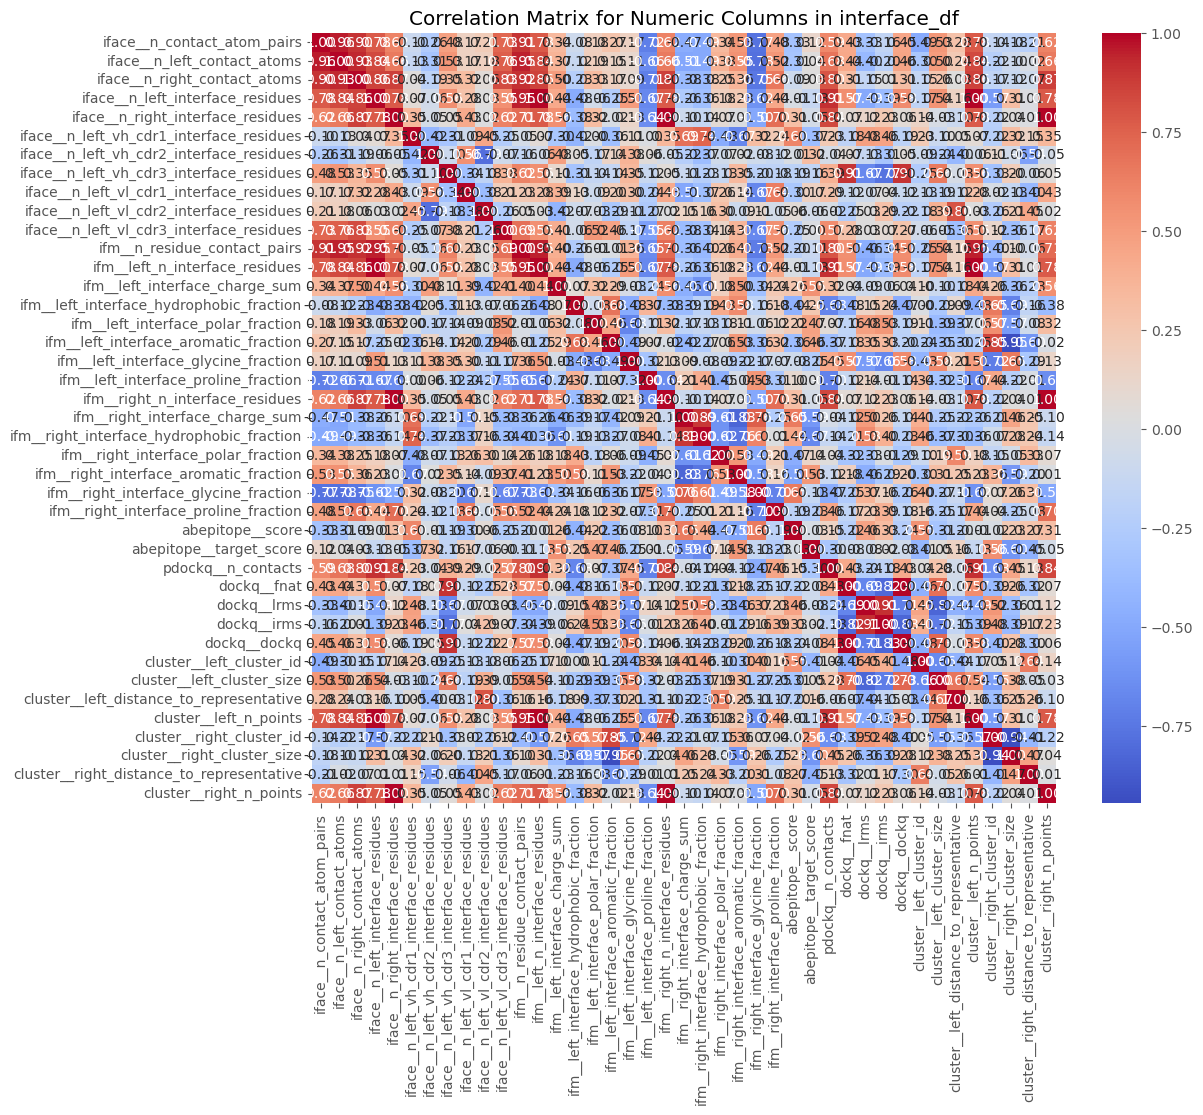

/tmp/ipykernel_32860/2364887936.py:27: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='ward')


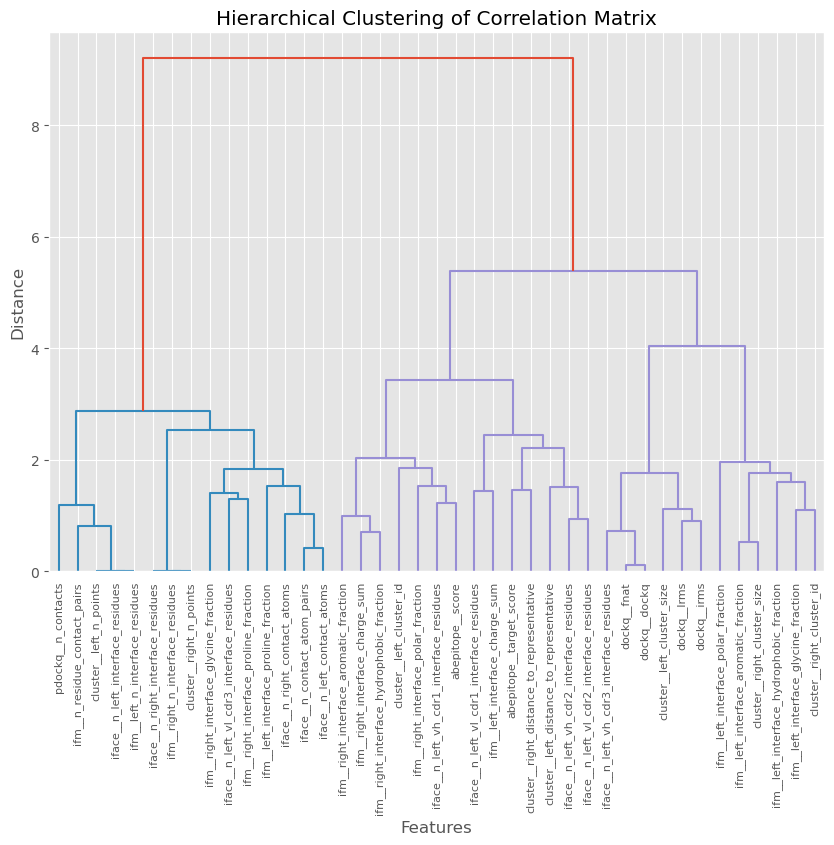

In [12]:
# data analysis for grain == interface
interface_df = grain_dfs['interface']
print(f'interface_df shape: {interface_df.shape}')
display(interface_df.head(20))

# check correlation between columns in interface_df for numeric columns
numeric_cols = interface_df.select_dtypes(include=[np.number]).columns
correlation_matrix = interface_df[numeric_cols].corr()
print('Correlation matrix for numeric columns in interface_df:')
display(correlation_matrix)

# plot correlation matrix as heatmap for column that is not all NaN
import seaborn as sns
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Columns in interface_df')
plt.show()

# cluster the correlation matrix using hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram
# drop columns that are all NaN
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
# compute the distance matrix
distance_matrix = 1 - correlation_matrix.abs()
# perform hierarchical clustering
linked = linkage(distance_matrix, method='ward')
# plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=correlation_matrix.columns, orientation='top')
plt.title('Hierarchical Clustering of Correlation Matrix')
#rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Distance')
plt.show()
